<a href="https://colab.research.google.com/github/DiPolanski/IA/blob/main/Balancemento_SMOTE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
!pip -q install plotly --upgrade

In [26]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from sklearn.processing import LabelEncoder

In [29]:
df_original = pd.read_csv("/content/heart-disease.csv")
df_original.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


# **Análise exploratória**

In [30]:
#shape dos dados
df_original.shape

(303, 14)

In [31]:
#tipos de dados
df_original.dtypes

,0
age,int64
sex,int64
cp,int64
trestbps,int64
chol,int64
fbs,int64
restecg,int64
thalach,int64
exang,int64
oldpeak,float64


In [32]:
#verificar valores faltantes
print(df_original.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


Não possui valores nulos


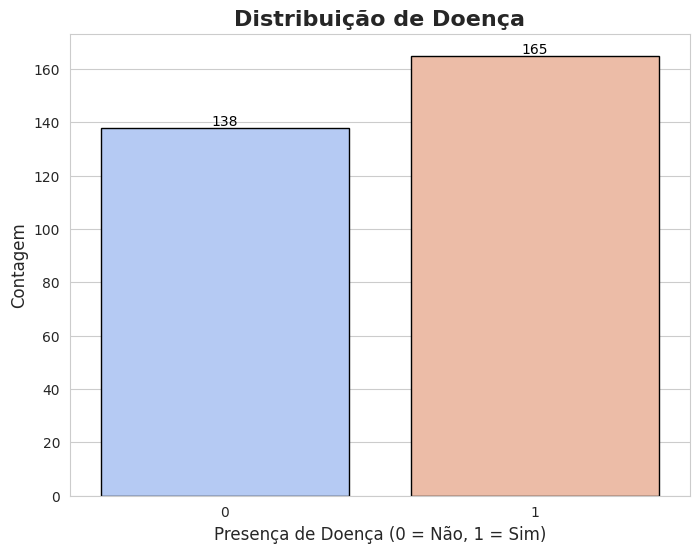

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configuração geral do estilo
sns.set_style("whitegrid")

# Subplot para ajustar o layout
plt.figure(figsize=(8, 6))  # Tamanho da figura
plt.subplot(1, 1, 1)  # Uma única plotagem para centralizar o gráfico

# Título e rótulos do gráfico
plt.title("Distribuição de Doença", fontsize=16, fontweight='bold')
plt.xlabel("Presença de Doença (0 = Não, 1 = Sim)", fontsize=12)
plt.ylabel("Contagem", fontsize=12)

# Gráfico de contagem com customização
sns.countplot(
    x=df_original['target'],  # Eixo X: coluna 'target'
    palette="coolwarm",       # Paleta de cores
    edgecolor="black"         # Borda das barras para maior contraste
)

# Exibição dos valores no topo das barras
for p in plt.gca().patches:
    plt.text(
        p.get_x() + p.get_width() / 2.,  # Coordenada X
        p.get_height() + 1,             # Coordenada Y
        f'{p.get_height():.0f}',        # Valor como texto
        ha='center', fontsize=10, color='black'
    )

# Exibir o gráfico
plt.show()


# **Balanceamento**

In [43]:
#Vizualizar os tipos de variáveis
df_original.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


Todos dados já são numéricos.

In [44]:
# Importa a função
from imblearn import under_sampling, over_sampling
from imblearn.over_sampling import SMOTE

seed = 100

# Separa X e Y
x = df_original.iloc[:, 0:13]
y = df_original.iloc[:, 13]

# Cria o balanceamento SMOTE
smote_bal = SMOTE(random_state=seed)

# Aplicação do balancemaneto
x_res, y_res = smote_bal.fit_resample(x, y)

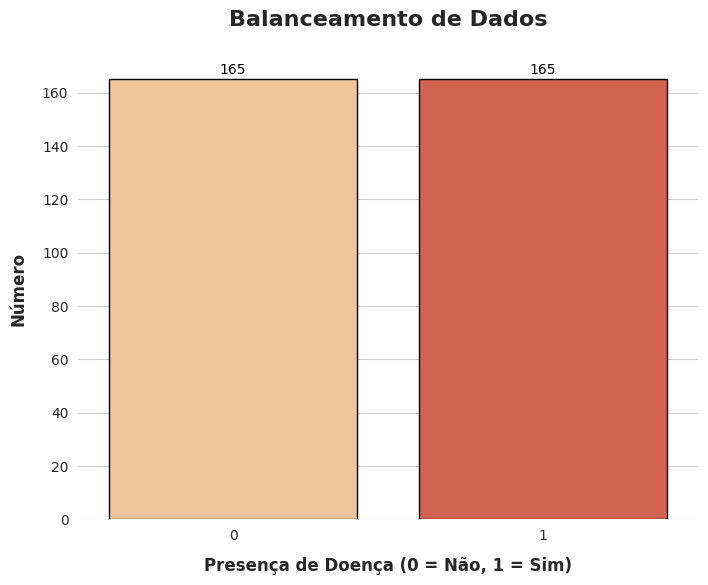

In [50]:
# Plot
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar o estilo geral
sns.set_style("whitegrid")

# Criar o gráfico
plt.figure(figsize=(8, 6))  # Ajustar o tamanho do gráfico
sns.countplot(
    x=y_res,                # Eixo X com os dados
    palette="OrRd",         # Paleta de cores
    edgecolor="black"       # Adicionar bordas pretas às barras
)

# Remover borda externa do gráfico
plt.box(False)

# Melhorar os rótulos e título
plt.xlabel('Presença de Doença (0 = Não, 1 = Sim)', fontsize=12, fontweight='bold', labelpad=10)
plt.ylabel('Número', fontsize=12, fontweight='bold', labelpad=10)
plt.title('Balanceamento de Dados\n', fontsize=16, fontweight='bold')

# Adicionar valores no topo das barras
for p in plt.gca().patches:
    plt.text(
        p.get_x() + p.get_width() / 2,  # Coordenada X
        p.get_height() + 1,            # Coordenada Y
        f'{p.get_height():.0f}',       # Valor arredondado
        ha='center', va='bottom', fontsize=10, color='black'
    )

# Exibir o gráfico
plt.show()

